# Kvasir-VQA x1: bias/health check

Goals:
- Quantify split sizes, sources, question/answer types.
- Check ulcerative colitis (UC) coverage and yes/no skew.
- Spot potential bias (dominant sources, answer imbalance).
Outputs saved to `1_dataset_analysis/out/`.


In [12]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="talk", style="whitegrid")


In [13]:
# Paths

def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root containing '0_dataset_prep'. cwd={start}")

DATA_ROOT = find_dataset_root()
META_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "metadata_enriched.csv"
OUT_DIR = DATA_ROOT / "1_dataset_analysis" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data root:", DATA_ROOT)
print("Metadata:", META_CSV)
print("Out dir:", OUT_DIR)


Data root: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1
Metadata: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/0_dataset_prep/out/metadata/metadata_enriched.csv
Out dir: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/1_dataset_analysis/out


In [14]:
# Load
meta = pd.read_csv(META_CSV)
print("Rows:", len(meta))
print("Columns:", list(meta.columns))
print(meta.head())


Rows: 58849
Columns: ['split', 'img_id', 'image_path', 'question', 'answer', 'question_type', 'answer_type', 'orig_height', 'orig_width']
   split                     img_id  \
0  train  cla820gl0s3nv071u4fgd7xgq   
1  train  cla820gl0s3nv071u4fgd7xgq   
2  train  cla820gl0s3nv071u4fgd7xgq   
3  train  cla820gl0s3nv071u4fgd7xgq   
4  train  cla820gl0s3nv071u4fgd7xgq   

                                     image_path  \
0  out/images/raw/cla820gl0s3nv071u4fgd7xgq.jpg   
1  out/images/raw/cla820gl0s3nv071u4fgd7xgq.jpg   
2  out/images/raw/cla820gl0s3nv071u4fgd7xgq.jpg   
3  out/images/raw/cla820gl0s3nv071u4fgd7xgq.jpg   
4  out/images/raw/cla820gl0s3nv071u4fgd7xgq.jpg   

                                            question              answer  \
0  Are there any abnormalities in the image? Chec...  ulcerative colitis   
1  Are there any anatomical landmarks in the imag...                none   
2  Are there any instruments in the image? Check ...                none   
3               

In [15]:
# Derive simple question/answer types
import re

def classify_answer_type(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return 'unknown'
    t = text.strip().lower()
    if t in {'yes', 'no'}:
        return 'yes_no'
    if re.fullmatch(r'[0-9]+', t):
        return 'number'
    if ',' in t:
        return 'list'
    return 'open'

def classify_question_type(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return 'unknown'
    t = text.lower()
    if t.startswith(('is ', 'are ', 'does ', 'do ', 'has ', 'have ', 'can ')):
        return 'yes_no'
    if any(t.startswith(p) for p in ['how many', 'what is the number', 'count']):
        return 'counting'
    if any(k in t for k in ['what', 'which', 'identify', 'name']):
        return 'open'
    return 'other'

if 'answer' in meta:
    meta['answer_type'] = meta['answer'].apply(classify_answer_type)
if 'question' in meta:
    meta['question_type'] = meta['question'].apply(classify_question_type)

print('Derived answer_type counts:', meta.get('answer_type', pd.Series(dtype=str)).value_counts())
print('Derived question_type counts:', meta.get('question_type', pd.Series(dtype=str)).value_counts())


Derived answer_type counts: answer_type
open       33437
yes_no     15243
number     10118
unknown       51
Name: count, dtype: int64
Derived question_type counts: question_type
yes_no      26515
open        13741
counting    10118
other        8475
Name: count, dtype: int64


In [16]:
# Nulls and splits
print("Nulls per column:", meta.isnull().sum())
print("Splits:", meta.get("split", pd.Series(dtype=str)).value_counts())

Nulls per column: split             0
img_id            0
image_path        0
question          0
answer           51
question_type     0
answer_type       0
orig_height       0
orig_width        0
dtype: int64
Splits: split
train         46966
test           5952
validation     5931
Name: count, dtype: int64


In [17]:
# Source distribution (if present)
if "source" in meta:
    print("Sources:", meta["source"].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(y="source", data=meta, order=meta["source"].value_counts().index)
    plt.title("Source counts")
    plt.tight_layout()
    fp = OUT_DIR / "source_counts.png"
    plt.savefig(fp, dpi=200)
    plt.show()
    print("Saved:", fp)


Answer types: answer_type
open       33437
yes_no     15243
number     10118
unknown       51
Name: count, dtype: int64


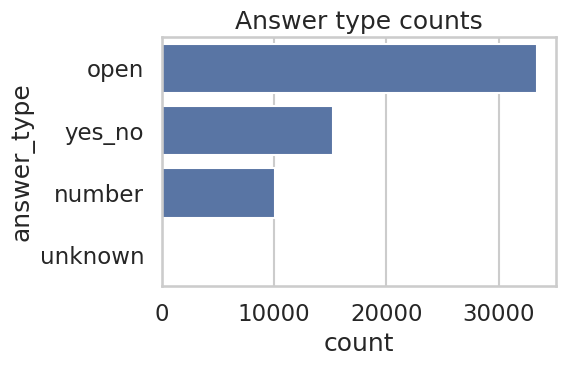

Saved: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/1_dataset_analysis/out/answer_type_counts.png
Question types: question_type
yes_no      26515
open        13741
counting    10118
other        8475
Name: count, dtype: int64


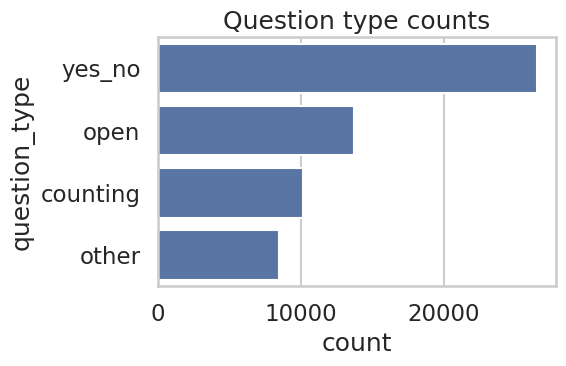

Saved: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/1_dataset_analysis/out/question_type_counts.png


In [18]:
# Answer type / Question type
if "answer_type" in meta:
    print("Answer types:", meta["answer_type"].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(y="answer_type", data=meta, order=meta["answer_type"].value_counts().index)
    plt.title("Answer type counts")
    plt.tight_layout()
    fp = OUT_DIR / "answer_type_counts.png"
    plt.savefig(fp, dpi=200)
    plt.show()
    print("Saved:", fp)
if "question_type" in meta:
    print("Question types:", meta["question_type"].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(y="question_type", data=meta, order=meta["question_type"].value_counts().index)
    plt.title("Question type counts")
    plt.tight_layout()
    fp = OUT_DIR / "question_type_counts.png"
    plt.savefig(fp, dpi=200)
    plt.show()
    print("Saved:", fp)


In [19]:
# Yes/No skew if applicable
if "answer" in meta:
    ans_norm = (
        meta["answer"].astype(str)
        .str.lower()
        .str.strip()
        .str.replace(r"[^a-z]", "", regex=True)
    )
    yn = meta[ans_norm.isin(["yes", "no"])].copy()
    if len(yn) > 0:
        print("Yes/No counts:", ans_norm.loc[yn.index].value_counts())


Yes/No counts: answer
no     8382
yes    6861
Name: count, dtype: int64


In [20]:
# UC-related coverage (simple keyword match)
if "source" in meta or "question" in meta or "answer" in meta:
    uc_mask = pd.Series(False, index=meta.index)
    for col in ["source","question","answer"]:
        if col in meta:
            uc_mask |= meta[col].astype(str).str.contains(r"\bulcerative colitis\b|\buc\b", case=False, na=False)
    uc_rows = meta[uc_mask]
    print("UC-related rows:", len(uc_rows))
    if len(uc_rows) > 0 and "answer_type" in meta:
        print("UC answer types:", uc_rows["answer_type"].value_counts())


UC-related rows: 997
UC answer types: answer_type
open    997
Name: count, dtype: int64


       question_len    answer_len
count  58849.000000  58849.000000
mean      40.139000     10.693351
std       15.611017     21.544287
min        4.000000      0.000000
25%       30.000000      2.000000
50%       36.000000      4.000000
75%       47.000000     11.000000
max       76.000000    111.000000


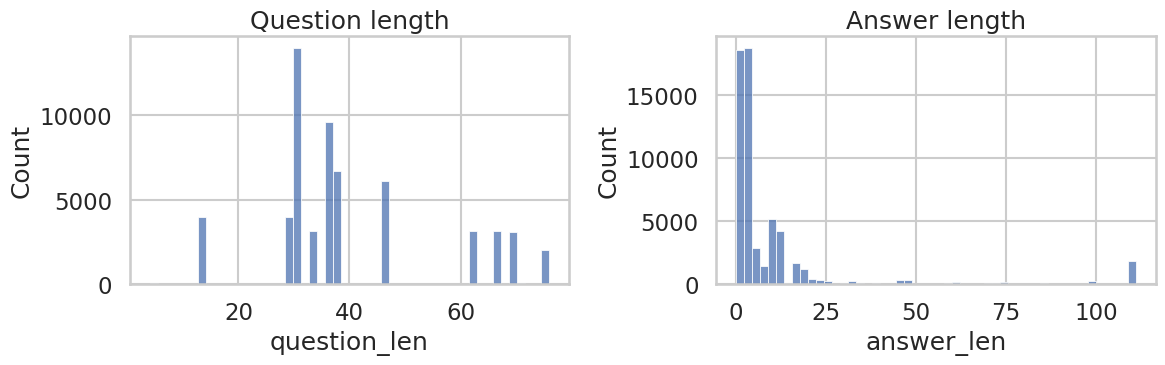

Saved: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/1_dataset_analysis/out/length_hists.png


In [21]:
# Text length stats
meta["question_len"] = meta["question"].fillna("").astype(str).str.len()
meta["answer_len"] = meta["answer"].fillna("").astype(str).str.len()
print(meta[["question_len", "answer_len"]].describe())

fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(meta["question_len"], bins=50, ax=axes[0])
axes[0].set_title("Question length")
sns.histplot(meta["answer_len"], bins=50, ax=axes[1])
axes[1].set_title("Answer length")
plt.tight_layout()
fp = OUT_DIR / "length_hists.png"
plt.savefig(fp, dpi=200)
plt.show()
print("Saved:", fp)


In [22]:
# Top answers and top question prefixes
print("Top answers:", meta["answer"].value_counts().head(10))
print("Top question prefixes:", meta["question"].astype(str).str[:30].value_counts().head(10))


Top answers: answer
none                                                                                                               10520
no                                                                                                                  8382
yes                                                                                                                 6861
0                                                                                                                   4538
1                                                                                                                   4380
not relevant                                                                                                        3024
colonoscopy                                                                                                         2944
center; center-left; center-right; lower-center; lower-left; lower-right; upper-center; upper-left; upper-right     1794
pink; red; w